In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Connexion base de données

In [2]:
DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\olist.db")

# Vérifier si le fichier existe pour éviter une erreur
if not DB_PATH.exists():
    raise FileNotFoundError(f"Fichier de base de données introuvable : {DB_PATH}")

# Établir la connexion
try:
    conn = sqlite3.connect(DB_PATH)
    print("Connexion à la base de données Olist réussie.")
except sqlite3.Error as e:
    print(f"Erreur de connexion : {e}")
    # Fonctions utilitaires
def run_query(conn, sql):
    df = pd.read_sql_query(sql, conn)
    return df

Connexion à la base de données Olist réussie.


# Vue d'ensemble du dataset

In [3]:
# Défini la requête SQL
query = """
SELECT name FROM sqlite_master WHERE type='table';
"""
# Stocker le résultat dans un DataFrame
df_tables = pd.read_sql_query(query, conn)

# Affichez le résultat
print(df_tables)


                   name
0             customers
1                geoloc
2           order_items
3           order_pymts
4         order_reviews
5                orders
6              products
7               sellers
8           translation
9          rfm_clusters
10  rfm_clusters_kmeans
11  rfm_clusters_dbscan
12     rfm_clusters_cah


In [4]:
#5 premières lignes de commandes
query_head = """
SELECT * FROM order_items LIMIT 5;
"""
df_head = pd.read_sql_query(query_head, conn)
print("\nAperçu des 5 premières lignes :")
print(df_head)


Aperçu des 5 premières lignes :
   index                          order_id  order_item_id  \
0      0  00010242fe8c5a6d1ba2dd792cb16214              1   
1      1  00018f77f2f0320c557190d7a144bdd3              1   
2      2  000229ec398224ef6ca0657da4fc703e              1   
3      3  00024acbcdf0a6daa1e931b038114c75              1   
4      4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:

In [5]:
q_counts = {
    "n_orders": "SELECT COUNT(*) AS n FROM orders;",
    "n_customer_rows": "SELECT COUNT(*) AS n FROM customers;",
    "n_unique_customers": "SELECT COUNT(DISTINCT customer_unique_id) AS n FROM customers;",
    "n_distinct_customer_id_in_orders": "SELECT COUNT(DISTINCT customer_id) AS n FROM orders;"
}
#le vrai nombre de clients ici est COUNT(DISTINCT customer_id)
out = {}
for k, q in q_counts.items():
    out[k] = pd.read_sql_query(q, conn)["n"][0]
pd.DataFrame.from_dict(out, orient="index", columns=["count"])

,count
n_orders,99441
n_customer_rows,99441
n_unique_customers,96096
n_distinct_customer_id_in_orders,99441


In [6]:
#Nombre de commandes
query_orders = """
SELECT COUNT(*) FROM orders;
"""
df_orders = pd.read_sql_query(query_orders, conn)
print("\nNombre total de commandes :")
print(df_orders)


Nombre total de commandes :
   COUNT(*)
0     99441


In [7]:
# Nombre d'articles commandés
query_items = """
SELECT COUNT(*) FROM order_items;
"""
df_items = pd.read_sql_query(query_items, conn)
print("\nNombre total d'articles commandés :")
print(df_items)



Nombre total d'articles commandés :
   COUNT(*)
0    112650


In [8]:
#Répartition du nombre de commandes par client (livrées)
q_dist = '''
WITH per_customer AS (
  SELECT c.customer_unique_id, COUNT(*) AS nb_orders
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
  GROUP BY c.customer_unique_id
)
SELECT nb_orders, COUNT(*) AS n_clients
FROM per_customer
GROUP BY nb_orders
ORDER BY nb_orders;
'''
dist_df = pd.read_sql_query(q_dist, conn)
dist_df

,nb_orders,n_clients
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


In [9]:
#valeurs uniques et fréquence

query_status = """
SELECT
    order_status,
    COUNT(order_id) AS n_orders
FROM orders
GROUP BY order_status
ORDER BY n_orders DESC;
"""

df_status = pd.read_sql_query(query_status, conn)

print("Distribution des statuts de commande :")
print(df_status)

Distribution des statuts de commande :
  order_status  n_orders
0    delivered     96478
1      shipped      1107
2     canceled       625
3  unavailable       609
4     invoiced       314
5   processing       301
6      created         5
7     approved         2


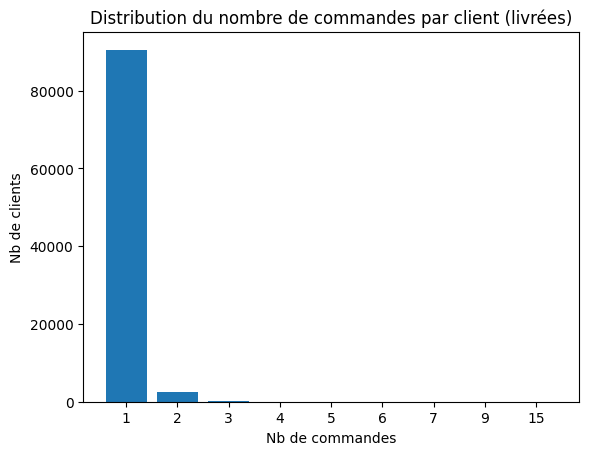

In [10]:
# Visualisation simple
plt.figure()
plt.bar(dist_df['nb_orders'].astype(str), dist_df['n_clients'])
plt.title("Distribution du nombre de commandes par client (livrées)")
plt.xlabel("Nb de commandes")
plt.ylabel("Nb de clients")
plt.show()

In [11]:
#distribution des montants par commande
query_prices = """
WITH delivered AS (
  SELECT o.order_id
  FROM orders o
  WHERE o.order_status = 'delivered'
),
per_order AS (
  SELECT d.order_id,
         SUM(oi.price + oi.freight_value) AS order_value,
         COUNT(*) AS item_count
  FROM delivered d
  JOIN order_items oi ON oi.order_id = d.order_id
  GROUP BY d.order_id
)
SELECT order_value, item_count
FROM per_order
ORDER BY order_value DESC;
"""
df_query_prices = pd.read_sql_query(query_prices, conn)

print("Distribution des montants par commande :")
print(df_query_prices)


Distribution des montants par commande :
       order_value  item_count
0         13664.08           8
1          7274.88           4
2          6929.31           1
3          6922.21           1
4          6726.66           1
...            ...         ...
96473        11.62           1
96474        11.56           1
96475        10.89           1
96476        10.07           1
96477         9.59           1

[96478 rows x 2 columns]


In [12]:
#Répartition des catégories produit
query_products = """
WITH delivered AS (
  SELECT o.order_id, o.customer_id
  FROM orders o
  WHERE o.order_status = 'delivered'
),
by_category AS (
  SELECT
    p.product_category_name AS category,
    SUM(oi.price)           AS revenue,
    COUNT(*)                AS n_items,
    COUNT(DISTINCT d.order_id)      AS n_orders,
    COUNT(DISTINCT d.customer_id)   AS n_customers
  FROM delivered d
  JOIN order_items oi ON oi.order_id = d.order_id
  JOIN products p     ON p.product_id = oi.product_id
  GROUP BY p.product_category_name
)
SELECT
  category,
  revenue,
  n_items,
  n_orders,
  n_customers
FROM by_category
ORDER BY revenue DESC
LIMIT 20;"""

df_query_products = pd.read_sql_query(query_products, conn)

print("Distribution des montants par commande :")
print(df_query_products)


Distribution des montants par commande :
                  category     revenue  n_items  n_orders  n_customers
0             beleza_saude  1233131.72     9465      8647         8647
1       relogios_presentes  1166176.98     5859      5495         5495
2          cama_mesa_banho  1023434.76    10953      9272         9272
3            esporte_lazer   954852.55     8431      7530         7530
4   informatica_acessorios   888724.61     7644      6530         6530
5         moveis_decoracao   711927.69     8160      6307         6307
6    utilidades_domesticas   615628.69     6795      5743         5743
7               cool_stuff   610204.10     3718      3559         3559
8               automotivo   578966.65     4140      3810         3810
9               brinquedos   471286.48     4030      3804         3804
10      ferramentas_jardim   470495.28     4268      3448         3448
11                   bebes   400421.84     2982      2809         2809
12              perfumaria   390144.

In [13]:
#Analyse des scores de review
query_review = """
SELECT
  CAST(review_score AS INTEGER) AS score,
  COUNT(*) AS n_reviews
FROM order_reviews
GROUP BY CAST(review_score AS INTEGER)
ORDER BY score;
"""

df_query_review = pd.read_sql_query(query_review, conn)

print("Distribution des scores de review :")
print(df_query_review)
#distribution très positive des notes 4 et 5 étoiles

Distribution des scores de review :
   score  n_reviews
0      1      11424
1      2       3151
2      3       8179
3      4      19142
4      5      57328


In [14]:
#valeurs NULL dans colonne 'order_delivered_customer_date'
query_null_dates = """
SELECT
    COUNT(*) AS n_null_delivery_dates
FROM orders
WHERE order_delivered_customer_date IS NULL;
"""

df_null_dates = pd.read_sql_query(query_null_dates, conn)

print("Nombre de commandes sans date de livraison :")
print(df_null_dates)

Nombre de commandes sans date de livraison :
   n_null_delivery_dates
0                   2965


In [15]:
# Détection des doublons de commandes
query_duplicates = """
SELECT
  order_id,
  COUNT(*) AS n_rows
FROM orders
GROUP BY order_id
HAVING order_id IS NULL OR COUNT(*) > 1
ORDER BY n_rows DESC, order_id;
"""

df_duplicates = pd.read_sql_query(query_duplicates, conn)

print("Détection de doublons d'identifiants de commande :")
print(df_duplicates)

if df_duplicates.empty:
    print("\nAucun doublon détecté pour 'order_id'.")
else:
    print("\nDes doublons ont été trouvés. Veuillez les examiner.")

Détection de doublons d'identifiants de commande :
Empty DataFrame
Columns: [order_id, n_rows]
Index: []

Aucun doublon détecté pour 'order_id'.


In [16]:
# Construction du fichier client
sql_client_file = """
WITH delivered AS (
  SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    DATE(o.order_purchase_timestamp) AS purchase_ts
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
),
max_date AS (
  SELECT MAX(purchase_ts) AS max_ts FROM delivered
),
per_order_value AS (
  SELECT
    d.order_id,
    SUM(oi.price + oi.freight_value) AS order_value
  FROM delivered d
  JOIN order_items oi ON oi.order_id = d.order_id
  GROUP BY d.order_id
),
rfm_base AS (
  SELECT
    d.customer_unique_id,
    MIN(d.purchase_ts)             AS first_order_date,
    MAX(d.purchase_ts)             AS last_order_date,
    COUNT(DISTINCT d.order_id)     AS n_orders,
    SUM(pov.order_value)           AS m_amount_total,
    AVG(pov.order_value)           AS m_amount_mean_order
  FROM delivered d
  JOIN per_order_value pov ON pov.order_id = d.order_id
  GROUP BY d.customer_unique_id
),
rfm AS (
  SELECT
    r.*,
    CAST(JULIANDAY(mx.max_ts) - JULIANDAY(r.last_order_date) AS INTEGER) AS days_since_last_order
  FROM rfm_base r
  CROSS JOIN max_date mx
),
cid_latest AS (
  -- on garde un customer_id représentatif (le plus récent)
  SELECT customer_unique_id, customer_id
  FROM (
    SELECT d.customer_unique_id, d.customer_id,
           ROW_NUMBER() OVER (PARTITION BY d.customer_unique_id ORDER BY d.purchase_ts DESC, d.order_id DESC) AS rn
    FROM delivered d
  )
  WHERE rn = 1
),
review_mean AS (
  SELECT d.customer_unique_id,
         AVG(CAST(rw.review_score AS REAL)) AS review_score_mean
  FROM order_reviews rw
  JOIN delivered d ON d.order_id = rw.order_id
  GROUP BY d.customer_unique_id
),
review_last AS (
  SELECT customer_unique_id, CAST(review_score AS INTEGER) AS review_score_last
  FROM (
    SELECT d.customer_unique_id, rw.review_score, rw.review_creation_date,
           ROW_NUMBER() OVER (PARTITION BY d.customer_unique_id ORDER BY rw.review_creation_date DESC) AS rn
    FROM order_reviews rw
    JOIN delivered d ON d.order_id = rw.order_id
  )
  WHERE rn = 1
)
SELECT
  cl.customer_id,
  r.first_order_date,
  r.last_order_date,
  r.days_since_last_order,   -- R
  r.n_orders,                -- F
  r.m_amount_total,          -- M total
  r.m_amount_mean_order,     -- M moyen par commande
  rm.review_score_mean,      -- optionnel - satisfaction globale du client
  rl.review_score_last       -- optionnel - satisfaction récente
FROM rfm r
JOIN cid_latest   cl ON cl.customer_unique_id = r.customer_unique_id
LEFT JOIN review_mean rm ON rm.customer_unique_id = r.customer_unique_id
LEFT JOIN review_last rl ON rl.customer_unique_id = r.customer_unique_id
ORDER BY r.m_amount_total DESC;
"""

df_clients = pd.read_sql_query(sql_client_file, conn)
df_clients.head()

,customer_id,first_order_date,last_order_date,days_since_last_order,n_orders,m_amount_total,m_amount_mean_order,review_score_mean,review_score_last
0,1617b1357756262bfa56ab541c47bc16,2017-09-29,2017-09-29,334,1,13664.08,13664.080,1.0,1.0
1,df55c14d1476a9a3467f131269c2477f,2017-04-01,2017-04-01,515,2,7571.63,3785.815,5.0,5.0
2,ec5b2ba62e574342386871631fafd3fc,2018-07-15,2018-07-15,45,1,7274.88,7274.880,1.0,1.0
3,c6e2731c5b391845f6800c97401a43a9,2017-02-12,2017-02-12,563,1,6929.31,6929.310,5.0,5.0
4,f48d464a0baaea338cb25f816991ab1f,2018-07-25,2018-07-25,35,1,6922.21,6922.210,NaN,NaN


# Scores RFM

In [17]:

# Requête RFM en utilisant des CTEs (Common Table Expressions)
query_rfm = """
WITH delivered AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        DATE(o.order_purchase_timestamp) AS purchase_ts
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
per_order_value AS (
    SELECT
        order_id,
        SUM(price + freight_value) AS order_value
    FROM order_items
    GROUP BY order_id
),
rfm_base AS (
    SELECT
        d.customer_unique_id,
        -- R (Recency) : sera calculé à l'étape suivante
        MAX(d.purchase_ts) AS last_order_date,
        -- F (Frequency)
        COUNT(d.order_id) AS frequency,
        -- M (Monetary)
        SUM(pov.order_value) AS monetary
    FROM delivered d
    JOIN per_order_value pov ON pov.order_id = d.order_id
    GROUP BY d.customer_unique_id
)
SELECT
    r.customer_unique_id,
    -- Calcul final de la Récence
    CAST(JULIANDAY((SELECT MAX(purchase_ts) FROM delivered)) - JULIANDAY(r.last_order_date) AS INTEGER) AS recency,
    r.frequency,
    r.monetary
FROM rfm_base r
ORDER BY r.monetary DESC;
"""

df_rfm = run_query(conn, query_rfm)
print("Aperçu du DataFrame RFM :")
print(df_rfm.head())

Aperçu du DataFrame RFM :
                 customer_unique_id  recency  frequency  monetary
0  0a0a92112bd4c708ca5fde585afaa872      334          1  13664.08
1  da122df9eeddfedc1dc1f5349a1a690c      515          2   7571.63
2  763c8b1c9c68a0229c42c9fc6f662b93       45          1   7274.88
3  dc4802a71eae9be1dd28f5d788ceb526      563          1   6929.31
4  459bef486812aa25204be022145caa62       35          1   6922.21


In [18]:
# Export pour le notebook de modélisation
from pathlib import Path
out = Path("exports"); out.mkdir(exist_ok=True)
df_rfm.to_csv(out / "clients_features_raw.csv", index=False)
print("Exporté ->", out / "clients_features_raw.csv")


Exporté -> exports\clients_features_raw.csv
